In [50]:
#!pip install nixtla

In [1]:

import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [2]:
## Load the data from file/files

In [3]:
#load data from cities

# 2. Read historic electricity demand data
df = pd.read_csv('fromCale/daily_data_nl.csv')
df

,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,10283.833333
1,2015-01-02 00:00:00+00:00,11931.250000
2,2015-01-03 00:00:00+00:00,12920.250000
3,2015-01-04 00:00:00+00:00,12529.250000
4,2015-01-05 00:00:00+00:00,15715.708333
...,...,...
1821,2019-12-27 00:00:00+00:00,13221.916667
1822,2019-12-28 00:00:00+00:00,12964.208333
1823,2019-12-29 00:00:00+00:00,12607.125000
1824,2019-12-30 00:00:00+00:00,13258.166667


## Select training data based on Scenario

In [4]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-10-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,NL_load_actual_entsoe_transparency
1096,2018-01-01 00:00:00+00:00,11692.250000
1097,2018-01-02 00:00:00+00:00,14106.333333
1098,2018-01-03 00:00:00+00:00,14755.000000
1099,2018-01-04 00:00:00+00:00,14686.291667
1100,2018-01-05 00:00:00+00:00,14471.375000
...,...,...
1394,2018-10-26 00:00:00+00:00,13899.416667
1395,2018-10-27 00:00:00+00:00,12058.791667
1396,2018-10-28 00:00:00+00:00,11434.458333
1397,2018-10-29 00:00:00+00:00,14216.250000


In [5]:
len(trainData)

303

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


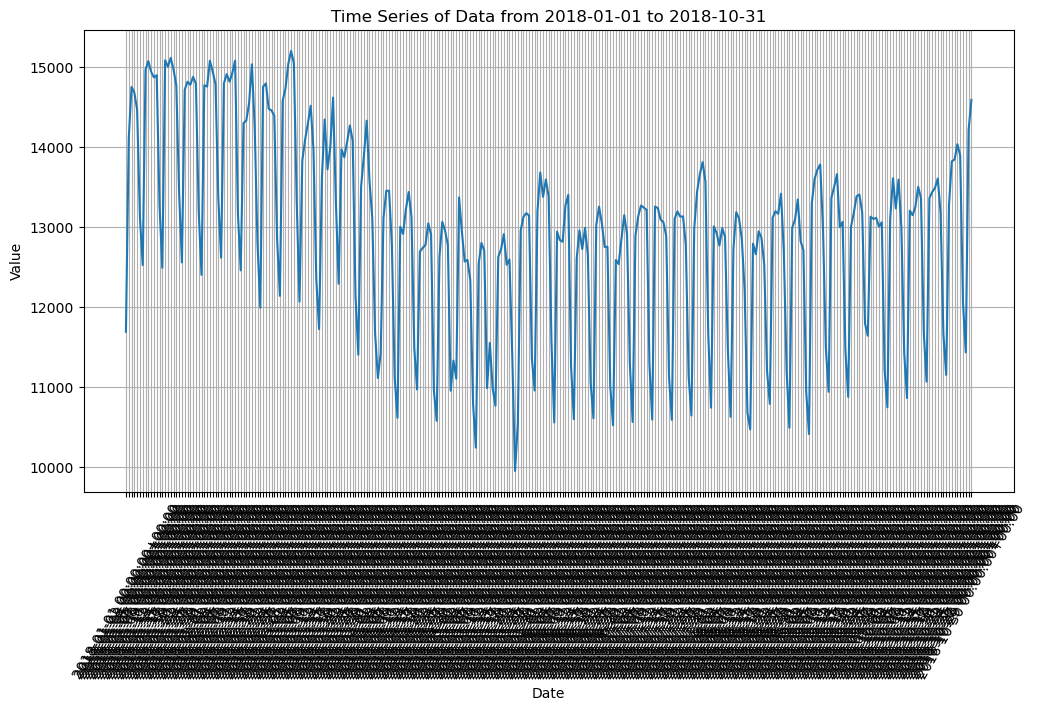

In [6]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(trainData['utc_timestamp'], trainData['NL_load_actual_entsoe_transparency'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Validation data selection based on scenario

In [7]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
1400,2018-11-01 00:00:00+00:00,14215.291667
1401,2018-11-02 00:00:00+00:00,13921.708333
1402,2018-11-03 00:00:00+00:00,12497.916667
1403,2018-11-04 00:00:00+00:00,11785.500000
1404,2018-11-05 00:00:00+00:00,14103.208333
1405,2018-11-06 00:00:00+00:00,14015.291667
1406,2018-11-07 00:00:00+00:00,14273.708333
1407,2018-11-08 00:00:00+00:00,14009.458333
1408,2018-11-09 00:00:00+00:00,14067.333333
1409,2018-11-10 00:00:00+00:00,12637.375000


In [8]:
len(validData)

60

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


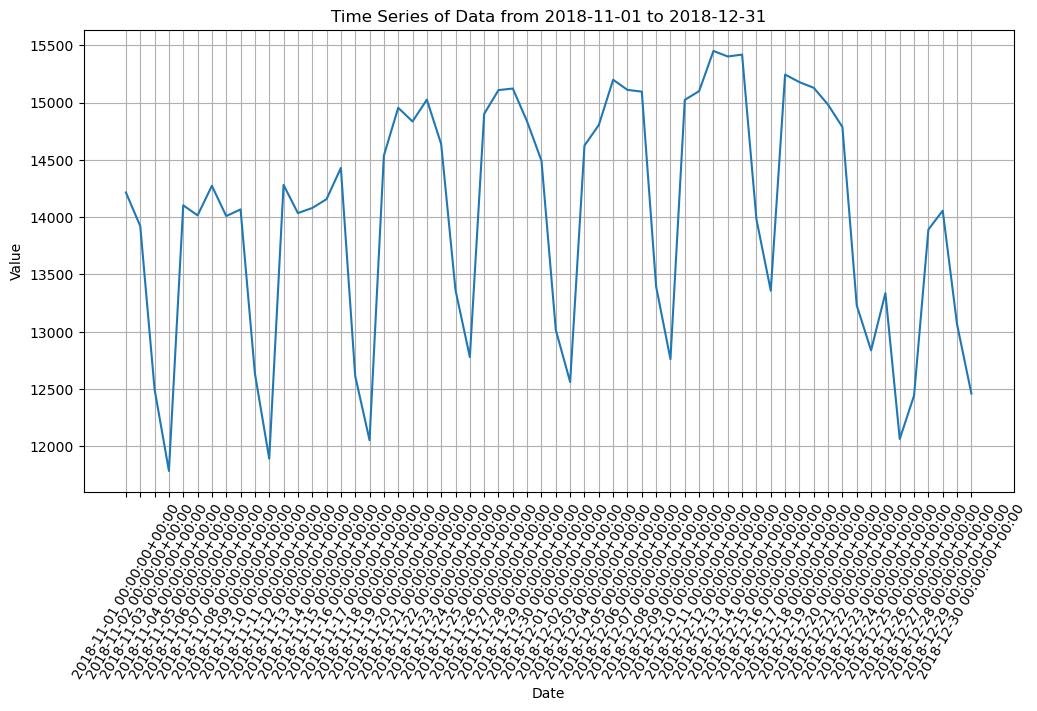

In [9]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(validData['ds'], validData['actual'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
   
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Forcasting wsith timeGPT

In [10]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='D',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [11]:
fcst_df

,ds,TimeGPT
0,2018-10-31 00:00:00+00:00,14051.469
1,2018-11-01 00:00:00+00:00,13948.878
2,2018-11-02 00:00:00+00:00,13532.163
3,2018-11-03 00:00:00+00:00,11619.413
4,2018-11-04 00:00:00+00:00,11248.189
5,2018-11-05 00:00:00+00:00,13573.614
6,2018-11-06 00:00:00+00:00,13887.114
7,2018-11-07 00:00:00+00:00,13851.949
8,2018-11-08 00:00:00+00:00,13759.180
9,2018-11-09 00:00:00+00:00,13336.468


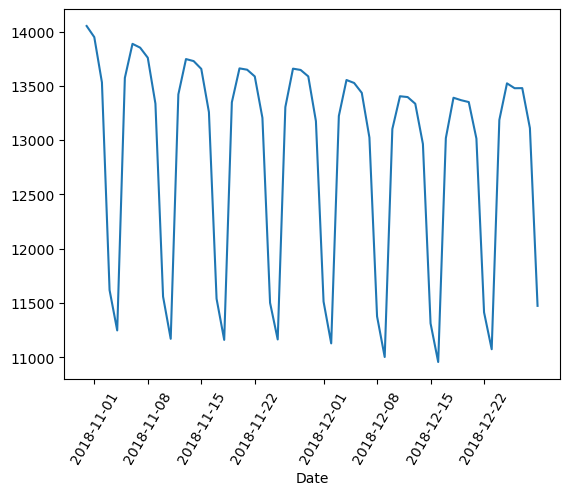

In [12]:
# Membuat plot
plt.plot(fcst_df['ds'], fcst_df['TimeGPT'])
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])
#plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees


# Menampilkan plot
plt.show()

## Merge forecast n actual

In [13]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [14]:
result

,ds,TimeGPT,actual
0,2018-11-01 00:00:00+00:00,13948.878,14215.291667
1,2018-11-02 00:00:00+00:00,13532.163,13921.708333
2,2018-11-03 00:00:00+00:00,11619.413,12497.916667
3,2018-11-04 00:00:00+00:00,11248.189,11785.500000
4,2018-11-05 00:00:00+00:00,13573.614,14103.208333
5,2018-11-06 00:00:00+00:00,13887.114,14015.291667
6,2018-11-07 00:00:00+00:00,13851.949,14273.708333
7,2018-11-08 00:00:00+00:00,13759.180,14009.458333
8,2018-11-09 00:00:00+00:00,13336.468,14067.333333
9,2018-11-10 00:00:00+00:00,11559.761,12637.375000


## Metrics calculation (rRMSE and rMAE)

In [15]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.1026 rMAE: 0.0924 


## Comparison of GPT vs Actual

In [16]:
city = 'Daily The Netherland TimeGPT'

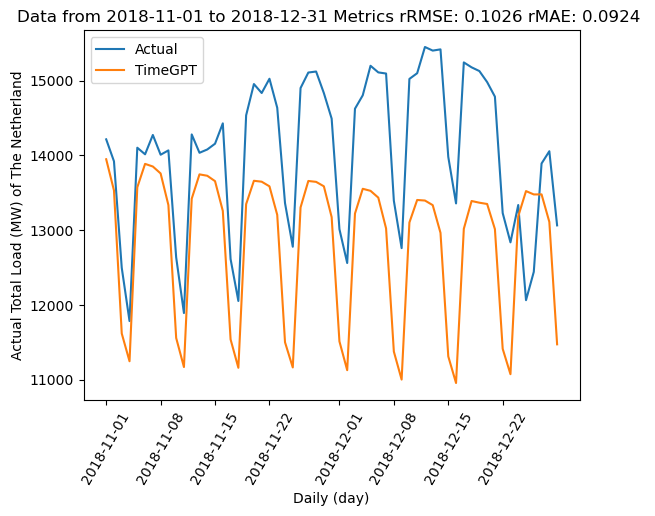

In [17]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Daily (day)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of The Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
